In [1]:
import pandas as pd

In [2]:
# 1. Load data
single = pd.read_csv("/scratch1/smaruj/single_insertions.tsv", sep="\t")
double_C = pd.read_csv("/scratch1/smaruj/double_insertions_C.tsv", sep="\t")
double_D = pd.read_csv("/scratch1/smaruj/double_insertions_D.tsv", sep="\t")
double_L = pd.read_csv("/scratch1/smaruj/double_insertions_L.tsv", sep="\t")
double_R = pd.read_csv("/scratch1/smaruj/double_insertions_R.tsv", sep="\t")

In [3]:
# 2. Add 'distance' column
for df in [double_C, double_D, double_L, double_R]:
    df["distance"] = 2 * df["spacer_bp"] + 60

In [4]:
# 3. Merge single with each double on chrom/start/end/strand
def merge_and_compare(double_df, name):
    merged = pd.merge(
        double_df,
        single,
        on=["chrom", "start", "end", "strand"],
        suffixes=(f"_{name}", "_single")
    )
    # Optionally select relevant columns
    merged = merged[[
        "chrom", "start", "end", "strand",
        f"SCD_{name}", "SCD_single", "distance"
    ]]
    merged.rename(columns={f"SCD_{name}": "SCD_double"}, inplace=True)
    return merged

In [5]:
merged_C = merge_and_compare(double_C, "C")
merged_D = merge_and_compare(double_D, "D")
merged_L = merge_and_compare(double_L, "L")
merged_R = merge_and_compare(double_R, "R")

In [6]:
merged_C

,chrom,start,end,strand,SCD_double,SCD_single,distance
0,chr7,37357852,37357871,-,77.10,67.60,60
1,chr4,87368249,87368268,+,70.70,65.75,60
2,chr2,172216028,172216047,-,74.60,65.06,60
3,chr14,87452272,87452291,-,74.20,63.00,60
4,chr8,112046077,112046096,+,72.60,62.60,60
...,...,...,...,...,...,...,...
97795,chr17,40824041,40824060,-,26.03,34.28,1000058
97796,chr17,88641230,88641249,-,24.02,34.25,1000058
97797,chr14,72293972,72293991,-,26.83,34.20,1000058
97798,chr3,52254069,52254088,+,25.03,34.16,1000058


In [7]:
import matplotlib.pyplot as plt

In [10]:
merged_C_min = merged_C[merged_C["distance"] == 152]

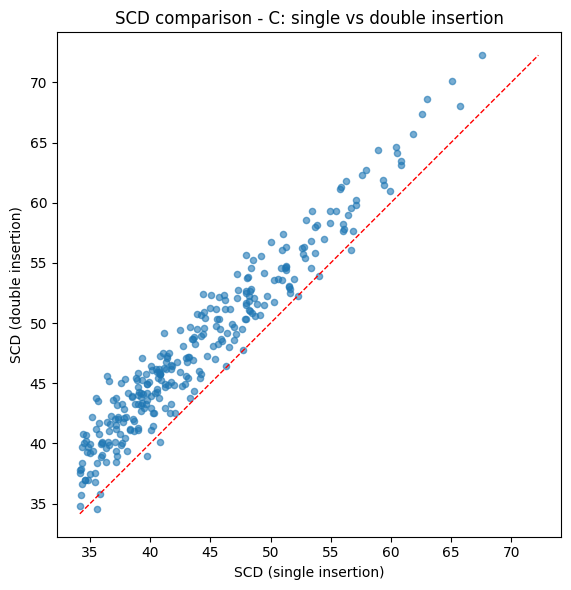

In [12]:
# Basic scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(merged_C_min['SCD_single'], merged_C_min['SCD_double'], alpha=0.6, s=20)

# Add x=y line
min_val = min(merged_C_min['SCD_single'].min(), merged_C_min['SCD_double'].min())
max_val = max(merged_C_min['SCD_single'].max(), merged_C_min['SCD_double'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

# Labels and style
plt.xlabel('SCD (single insertion)')
plt.ylabel('SCD (double insertion)')
plt.title('SCD comparison - C: single vs double insertion')
plt.axis('square')
plt.tight_layout()
plt.show()

In [15]:
merged_D_min = merged_D[merged_D["distance"] == 152]

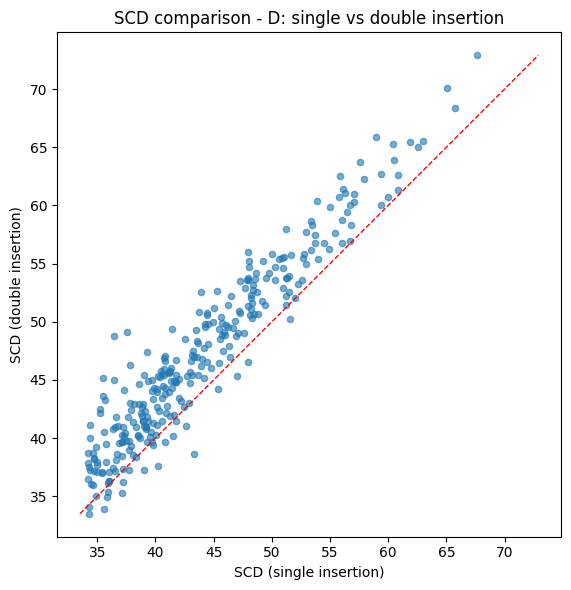

In [16]:
# Basic scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(merged_D_min['SCD_single'], merged_D_min['SCD_double'], alpha=0.6, s=20)

# Add x=y line
min_val = min(merged_D_min['SCD_single'].min(), merged_D_min['SCD_double'].min())
max_val = max(merged_D_min['SCD_single'].max(), merged_D_min['SCD_double'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

# Labels and style
plt.xlabel('SCD (single insertion)')
plt.ylabel('SCD (double insertion)')
plt.title('SCD comparison - D: single vs double insertion')
plt.axis('square')
plt.tight_layout()
plt.show()

In [17]:
merged_L_min = merged_L[merged_L["distance"] == 152]

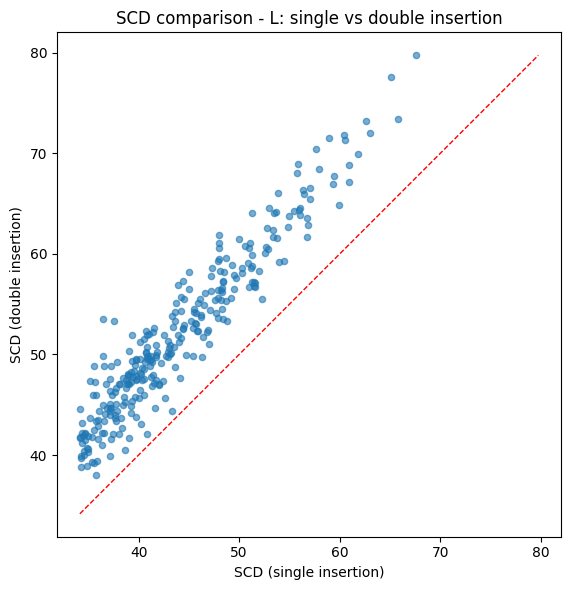

In [18]:
# Basic scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(merged_L_min['SCD_single'], merged_L_min['SCD_double'], alpha=0.6, s=20)

# Add x=y line
min_val = min(merged_L_min['SCD_single'].min(), merged_L_min['SCD_double'].min())
max_val = max(merged_L_min['SCD_single'].max(), merged_L_min['SCD_double'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

# Labels and style
plt.xlabel('SCD (single insertion)')
plt.ylabel('SCD (double insertion)')
plt.title('SCD comparison - L: single vs double insertion')
plt.axis('square')
plt.tight_layout()
plt.show()

In [19]:
merged_R_min = merged_R[merged_R["distance"] == 152]

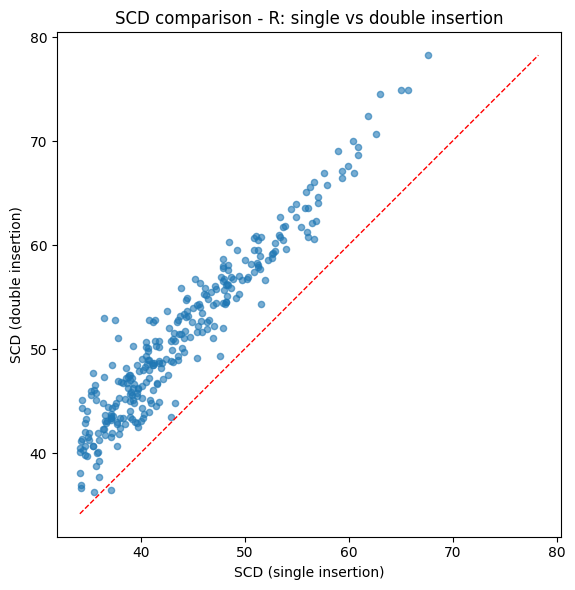

In [20]:
# Basic scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(merged_R_min['SCD_single'], merged_R_min['SCD_double'], alpha=0.6, s=20)

# Add x=y line
min_val = min(merged_R_min['SCD_single'].min(), merged_R_min['SCD_double'].min())
max_val = max(merged_R_min['SCD_single'].max(), merged_R_min['SCD_double'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

# Labels and style
plt.xlabel('SCD (single insertion)')
plt.ylabel('SCD (double insertion)')
plt.title('SCD comparison - R: single vs double insertion')
plt.axis('square')
plt.tight_layout()
plt.show()

In [ ]:
def summarize(df, label):
    summary = df.groupby("distance", as_index=False)["SCD_double"].mean()
    summary["type"] = label
    return summary

In [ ]:
# Summarize each dataset
summary_C = summarize(merged_C, "C")
summary_D = summarize(merged_D, "D")
summary_L = summarize(merged_L, "L")
summary_R = summarize(merged_R, "R")

In [ ]:
# Combine summaries
summary_all = pd.concat([summary_C, summary_D, summary_L, summary_R])

# Compute overall mean SCD_single across overlapping single insertion sites
mean_scd_single = (
    pd.concat([merged_C, merged_D, merged_L, merged_R])["SCD_single"].mean()
)
print(f"Mean single insertion SCD: {mean_scd_single:.4f}")

# Plot
plt.figure(figsize=(8, 6))

for label, color in zip(["C", "D", "L", "R"], ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]):
    subset = summary_all[summary_all["type"] == label]
    plt.plot(subset["distance"], subset["SCD_double"], label=f"Double {label}", color=color, linewidth=2)

# Add horizontal line for mean SCD_single
plt.axhline(y=mean_scd_single, color="black", linestyle="--", linewidth=1.5, label="Mean single insertion SCD")

# Formatting
plt.xlabel("Distance (bp)")
plt.ylabel("Average SCD_double")
plt.title("Average SCD_double vs. distance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def summarize_dist(df, label):
    df_filtered = df[df["distance"] <= 2048].reset_index(drop=True)
    summary = df_filtered.groupby("distance", as_index=False)["SCD_double"].mean()
    summary["type"] = label
    return summary

In [ ]:
summary_d_C = summarize_dist(merged_C, "C")
summary_d_D = summarize_dist(merged_D, "D")
summary_d_L = summarize_dist(merged_L, "L")
summary_d_R = summarize_dist(merged_R, "R")

In [ ]:
# Combine summaries
summary_d_all = pd.concat(
    [summary_d_C, summary_d_D, summary_d_L, summary_d_R],
    ignore_index=True
)

# Compute mean single-insertion SCD (for overlapping regions)
mean_scd_single = merged_C["SCD_single"].mean()

print(f"Mean single insertion SCD: {mean_scd_single:.4f}")

In [ ]:
# Plot
plt.figure(figsize=(8, 6))

for label, color in zip(["C", "D", "L", "R"], ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]):
    subset = summary_d_all[summary_d_all["type"] == label]
    plt.plot(subset["distance"], subset["SCD_double"], label=f"Double {label}", color=color, linewidth=2)

# Add horizontal line for mean SCD_single
plt.axhline(y=mean_scd_single, color="black", linestyle="--", linewidth=1.5, label="Mean single insertion SCD")

# Formatting
plt.xlabel("Distance (bp)")
plt.ylabel("Average SCD_double")
plt.title("Average SCD_double vs. distance (0–2048 bp)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Filter merged_C for distances 0-2048 bp
# subset = merged_C[merged_C["distance"] <= 2048].copy()
# subset = merged_D[merged_D["distance"] <= 2048].copy()
# subset = merged_L[merged_L["distance"] <= 2048].copy()
subset = merged_R[merged_R["distance"] <= 2048].copy()

# 2. For each genomic location, take the minimum SCD_double
min_double = subset.groupby(["chrom", "start", "end", "strand", "SCD_single"], as_index=False)["SCD_double"].min()

In [ ]:
min_double

In [ ]:
# 4. Prepare x positions for plotting
x_single = 0
x_double = 1

plt.figure(figsize=(6, 6))

# Plot lines connecting single -> double for each location
for _, row in min_double.iterrows():
    plt.plot([x_single, x_double], [row["SCD_single"], row["SCD_double"]],
             color="gray", alpha=0.5)

# Plot the points themselves
plt.scatter([x_single]*len(min_double), min_double["SCD_single"], color="blue", label="Single insertion")
plt.scatter([x_double]*len(min_double), min_double["SCD_double"], color="red", label="Double R insertion (min)")

# Formatting
plt.xticks([x_single, x_double], ["Single", "Double R"])
plt.ylabel("SCD")
plt.title("Change in SCD from single to double insertion (distance 100-200 bp)")
plt.legend()
plt.tight_layout()
plt.show()